In [16]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 9,                    # Base font size
    "axes.labelsize": 9,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})

import pickle


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/Light_House_DBS/light_house_DBS_decision_making


# PD Vs DBS

### Data Analysis

In [17]:
lat_arr = [0.0275, 0.0325, 0.0375, 0.0425, 0.0475]
del_lim_arr = [0.1, 0.2, 0.5, 1.0]
Mean_PD_all = []
Mean_std_DBS_all = []
Mean_sector_DBS_all = []

for i in range(len(lat_arr)):
    lat_str = str(lat_arr[i]).replace('.', '_')
    if i == 1:
        data_file = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'restless_bandits', 'restless_bandits_data_lat_'+ lat_str + '_1.pkl')
        with open(data_file, 'rb') as f:
            data = pickle.load(f)
    elif i == 0:
        data_file = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'restless_bandits', 'restless_bandits_data_lat_'+ lat_str + '_2.pkl')
        with open(data_file, 'rb') as f:
            data = pickle.load(f)
    else:
        data_file = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'restless_bandits', 'restless_bandits_data_lat_'+ lat_str + '.pkl')
        with open(data_file, 'rb') as f:
            data = pickle.load(f)
    del_lim_arr = data['DEL_LIM_ARR']
    lat_strength = data['LAT_STRENGTH']
    prob_optimal_monitor = data['PROB_OPTIMAL_MONITOR']
    mean_prob_monitor = data['MEAN_PROB_MONITOR']
    Mean_Probs_PD = [mean_prob_monitor['PD'][del_lim] for del_lim in del_lim_arr]
    Mean_Probs_std_DBS = [mean_prob_monitor['STD_DBS'][del_lim] for del_lim in del_lim_arr]
    Mean_Probs_sector_DBS = [mean_prob_monitor['SECTOR_DBS'][del_lim] for del_lim in del_lim_arr]

    Mean_PD_all.append(Mean_Probs_PD)
    Mean_std_DBS_all.append(Mean_Probs_std_DBS)
    Mean_sector_DBS_all.append(Mean_Probs_sector_DBS)
        

In [18]:
# plt.figure(figsize=(3, 2))
# for i in range(5):
#     plt.scatter(np.arange(4), Mean_PD_all[i], marker='d', color='r', s=5)
#     plt.scatter(np.arange(4), Mean_std_DBS_all[i], marker='s', color='b', s=5)
#     plt.scatter(np.arange(4), Mean_sector_DBS_all[i], marker='*', color='g', s=5)
#     plt.plot(np.arange(4), Mean_PD_all[i], color='r', linewidth=0.5, alpha=0.2, linestyle='dotted')
#     plt.plot(np.arange(4), Mean_std_DBS_all[i], color='b', linewidth=0.5, alpha=0.2, linestyle='dotted')
#     plt.plot(np.arange(4), Mean_sector_DBS_all[i], color='g', linewidth=0.5, alpha=0.5, linestyle='dotted')
#     plt.xlabel('Del limit (s)')
#     plt.ylabel('Mean probability')
#     plt.xticks(np.arange(4), del_lim_arr)


# Normal

In [19]:
# Reading normal data
data_file_normal = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'restless_bandits', 'normal_data_1.pkl')

# Read pickle file
with open(data_file_normal, 'rb') as f:
    normal_data = pickle.load(f)


In [20]:
EPOCH_NUM = 3
arm_chosen_monitor_normal = normal_data['arm_chosen_monitor']
reward_monitor_normal = normal_data['reward_monitor'] # recieved rew
dp_monitor_normal = normal_data['dp_monitor']
ip_monitor_normal = normal_data['ip_monitor']
arm_tracker_full_normal = normal_data['arm_tracker_full']
prob_normal = normal_data['prob']
mean_prob_normal = normal_data['mean_prob']
trials_normal = arm_chosen_monitor_normal.shape[1]
epochs_normal = arm_chosen_monitor_normal.shape[0]
num_arms = 4
# arm_means_normal = arm_tracker_full_normal[EPOCH_NUM]
# arm_rew_normal = np.zeros((num_arms, len(arm_means_normal)))
# for i in range(len(arm_means_normal)):
#     arms = arm_means_normal[i]
#     rews = np.array([arms[0][0], arms[1][0], arms[2][0], arms[3][0]])
#     arm_rew_normal[:,i] = rews

# PD

In [21]:
# Reading PD data
data_file_PD = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'restless_bandits', 'PD_data.pkl')

# Read pickle file
with open(data_file_PD, 'rb') as f:
    PD_data = pickle.load(f)


In [22]:
EPOCH_NUM = 8
arm_chosen_monitor_PD = PD_data['arm_chosen_monitor']
reward_monitor_PD = PD_data['reward_monitor'] # recieved rew
dp_monitor_PD = PD_data['dp_monitor']
ip_monitor_PD = PD_data['ip_monitor']
arm_tracker_full_PD = PD_data['arm_tracker_full']
prob_PD = PD_data['prob']
mean_prob_PD = PD_data['mean_prob']
trials_PD = arm_chosen_monitor_PD.shape[1]
epochs_PD = arm_chosen_monitor_PD.shape[0]
num_arms = 4
# arm_means_PD = arm_tracker_full_PD[EPOCH_NUM]
# arm_rew_PD = np.zeros((num_arms, len(arm_means_PD)))
# for i in range(len(arm_means_PD)):
#     arms = arm_means_PD[i]
#     rews = np.array([arms[0][0], arms[1][0], arms[2][0], arms[3][0]])
#     arm_rew_PD[:,i] = rews

In [23]:
print(f'Mean prob normal: {np.mean(prob_normal)}, Mean prob PD: {np.mean(prob_PD)}')

Mean prob normal: 0.6213333333333334, Mean prob PD: 0.34973333333333334


# Grid plot

In [24]:
# Ensure epoch selections
EPOCH_NORMAL = 21
EPOCH_PD = 8

# Recompute arm rewards (if variables not in scope) — safe to reuse existing arrays if present
arm_means_normal = arm_tracker_full_normal[EPOCH_NORMAL]
arm_rew_normal = np.zeros((4, len(arm_means_normal)))
for i in range(len(arm_means_normal)):
    arms = arm_means_normal[i]
    arm_rew_normal[:, i] = np.array([arms[0][0], arms[1][0], arms[2][0], arms[3][0]])

arm_means_PD = arm_tracker_full_PD[EPOCH_PD]
arm_rew_PD = np.zeros((4, len(arm_means_PD)))
for i in range(len(arm_means_PD)):
    arms = arm_means_PD[i]
    arm_rew_PD[:, i] = np.array([arms[0][0], arms[1][0], arms[2][0], arms[3][0]])

# Pick maps for scatter markers (who was chosen)
chosen_normal = [int(x.detach().numpy()) for x in arm_chosen_monitor_normal[EPOCH_NORMAL]]
chosen_PD = [int(x.detach().numpy()) for x in arm_chosen_monitor_PD[EPOCH_PD]]

colors = {'normal':"#054b7c",
          'PD': "#9f0d03ff",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}


color_map_PD = {0: '#FF0000', 1: '#008000', 2: '#4682B4', 3: '#FFA500'}
color_map_normal = {0: '#FF0000', 1: '#008000', 2: '#4682B4', 3: '#FFA500'}

color_map_normal_scatter = {0: "#FF0000BB", 1: "#008000C4", 2: "#4683B4B6", 3: "#FFA600BD"}
color_map_PD_scatter = {0: "#FF0000BB", 1: "#008000C4", 2: "#4683B4B6", 3: "#FFA600BD"}



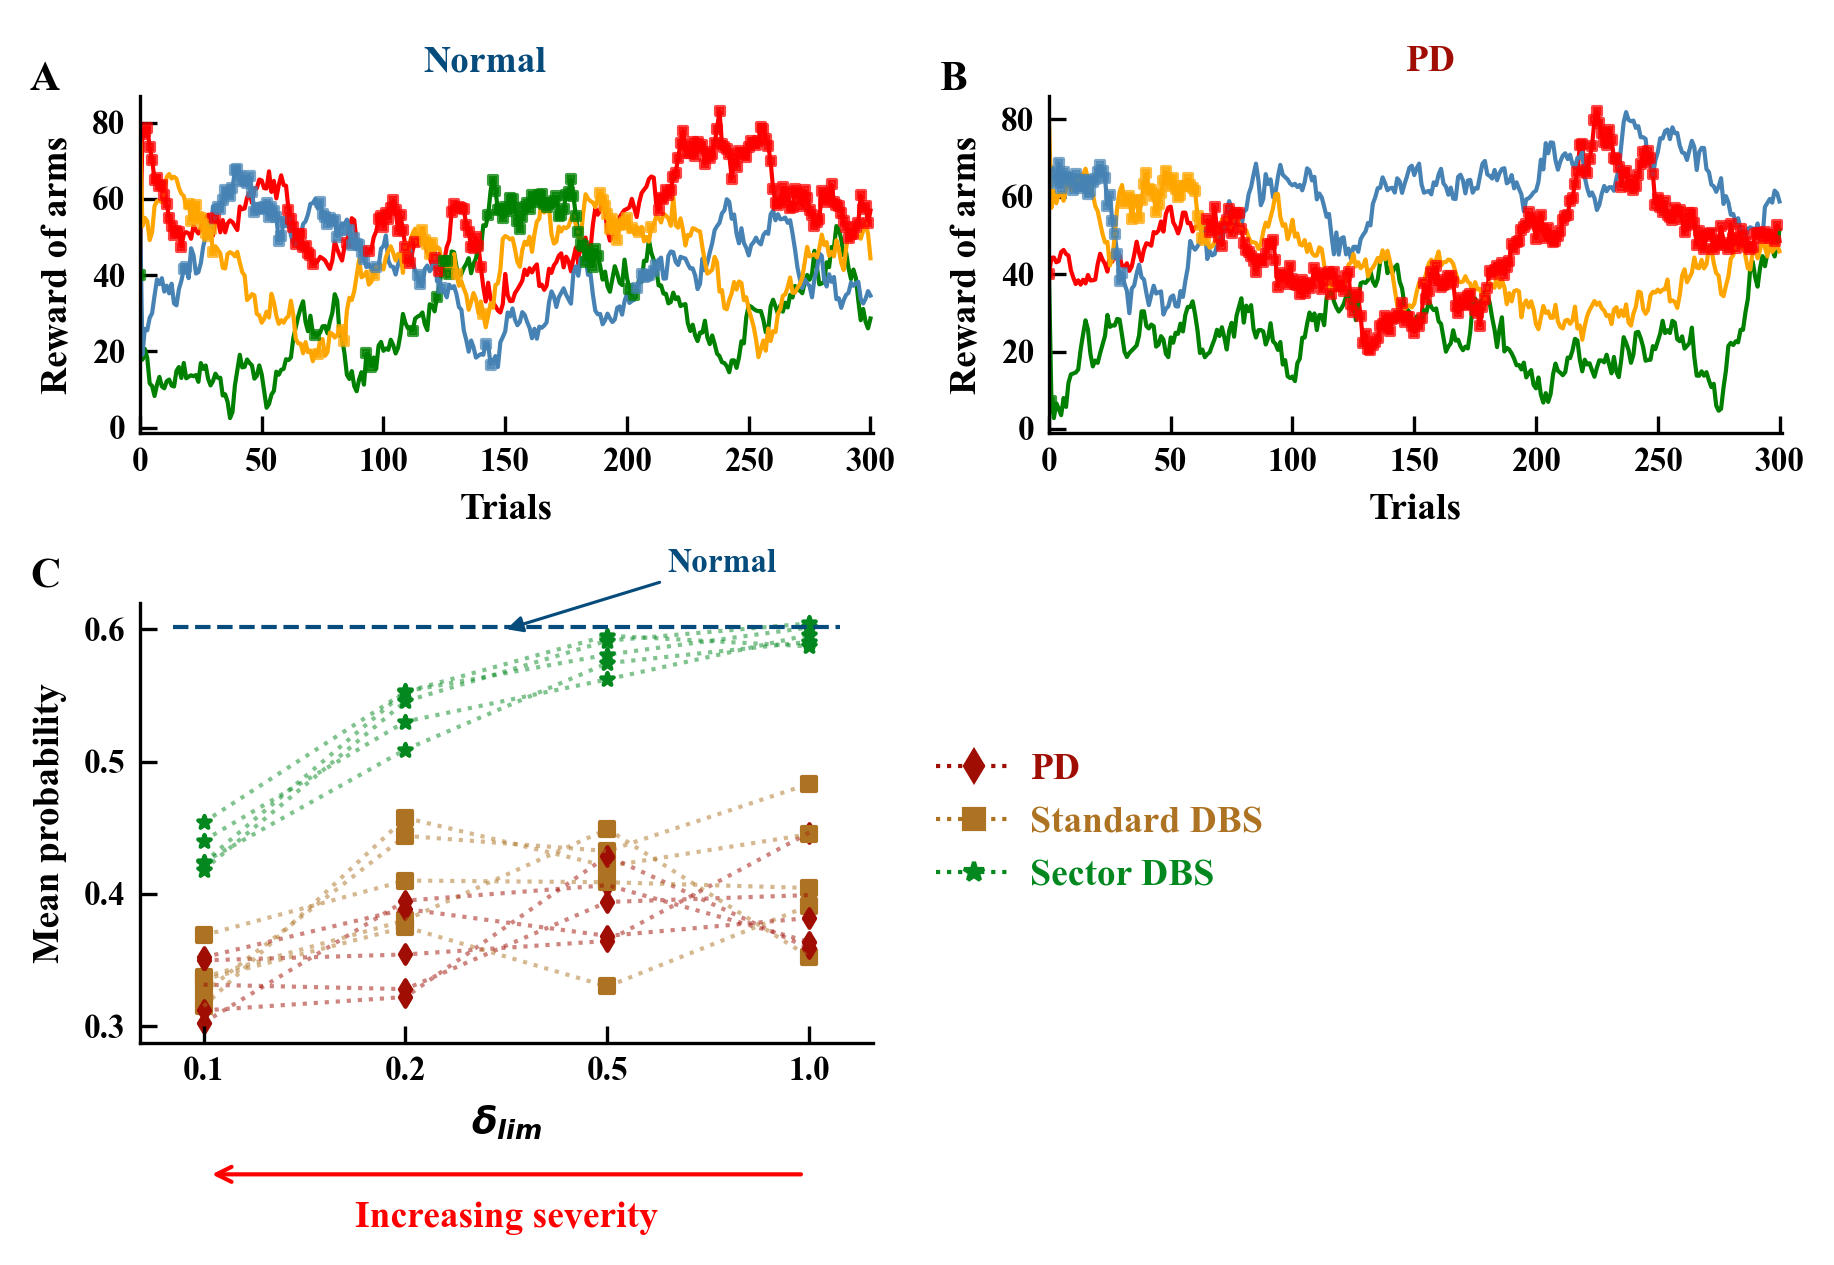

In [25]:

fig = plt.figure(figsize=(6, 4), facecolor='white')
gs = fig.add_gridspec(nrows=2, ncols=2, width_ratios=[1,1], height_ratios=[1, 1.3], hspace=0.01)

ax_normal = fig.add_subplot(gs[0, 0])   # top-left
ax_PD     = fig.add_subplot(gs[0, 1])   # top-right
ax_all    = fig.add_subplot(gs[1, 0]) # bottom spanning two columns
ax_legend  = fig.add_subplot(gs[1,1])  # narrow right column for legends

# hide legend axis background
ax_legend.axis('off')

# Top-left: Normal lines + picks
trials_normal = arm_rew_normal.shape[1]
time_normal = np.arange(trials_normal)
for i in range(4):
    ax_normal.plot(time_normal, arm_rew_normal[i, :]*100, color=color_map_normal[i], label=f'arm {i}', linewidth=1.0)
for t, pick in enumerate(chosen_normal):
    ax_normal.scatter(t, arm_rew_normal[pick, t]*100, color=color_map_normal_scatter[pick], s=3, marker='s', zorder = 2)
ax_normal.set_xlabel('Trials')
ax_normal.set_ylabel('Reward of arms')
ax_normal.set_xlim(0, trials_normal)

handles = [Line2D([0], [0], color=colors['normal'], lw=0)]
          
legend = ax_normal.legend(handles, ['Normal'], loc='upper right', frameon=False, fontsize=9, bbox_to_anchor=(0.6, 1.25))
for txt, col in zip(legend.get_texts(), [colors['normal']]):
    txt.set_color(col)


# Top-right: PD lines + picks
trials_PD = arm_rew_PD.shape[1]
time_PD = np.arange(trials_PD)
for i in range(4):
    ax_PD.plot(time_PD, arm_rew_PD[i, :]*100, color=color_map_PD[i], label=f'arm {i}', linewidth=1.0)
for t, pick in enumerate(chosen_PD):
    ax_PD.scatter(t, arm_rew_PD[pick, t]*100, color=color_map_PD_scatter[pick], s=3, marker='s', zorder = 2)
ax_PD.set_xlabel('Trials')
ax_PD.set_ylabel('Reward of arms')
ax_PD.set_xlim(0, trials_PD)
handles = [Line2D([0], [0], color=colors['PD'], lw=0)]
          
legend = ax_PD.legend(handles, ['PD'], loc='upper right', frameon=False, fontsize=9, bbox_to_anchor=(0.6, 1.25))
for txt, col in zip(legend.get_texts(), [colors['PD']]):
    txt.set_color(col)

for i in range(5):
    ax_all.scatter(np.arange(4), Mean_PD_all[i], marker='d', color=colors['PD'], s=10)
    ax_all.scatter(np.arange(4), Mean_std_DBS_all[i], marker='s', color= colors['std_DBS'], s=10)
    ax_all.scatter(np.arange(4), Mean_sector_DBS_all[i], marker='*', color=colors['sector_DBS'], s=10)
    ax_all.plot(np.arange(4), Mean_PD_all[i], color=colors['PD'], linewidth=1, alpha=0.5, linestyle='dotted')
    ax_all.plot(np.arange(4), Mean_std_DBS_all[i], color=colors['std_DBS'], linewidth=1, alpha=0.5, linestyle='dotted')
    ax_all.plot(np.arange(4), Mean_sector_DBS_all[i], color= colors['sector_DBS'], linewidth=1, alpha=0.5, linestyle='dotted')


ax_all.set_xlabel('$\delta_{lim}$')
ax_all.set_ylabel('Mean probability')
ax_all.set_xticks(np.arange(4), del_lim_arr)

x_min, x_max = ax_all.get_xlim()
ax_all.hlines(np.mean(prob_normal)-0.02, x_min, x_max, color=colors['normal'], linestyle='--', linewidth=1.0)
x_ann = x_min + 0.5 * (x_max - x_min)               # near left/y-axis
y_ann = 0.6
y_text = 0.65

ax_all.annotate(
    'Normal',
    xy=(x_ann, y_ann),
    xytext=(x_ann + 0.8, y_text),
    arrowprops=dict(arrowstyle='-|>', color=colors['normal'], lw=0.75, shrinkA=0, shrinkB=0),
    fontsize=8, fontweight='bold', color=colors['normal'], va='center'
)

x_values = np.arange(len(del_lim_arr))
x_start = x_values[-1] 
x_end = x_values[0] 
y_pos = -0.3
ax_all.annotate(
    '',  # No text at the arrow tip
    xy=(x_end, y_pos),           # Arrow tip coordinates (end point)
    xytext=(x_start, y_pos),     # Text and arrow tail coordinates (start point)
    xycoords=('data', 'axes fraction'), # Use data coords for x, axes fraction for y
    textcoords=('data', 'axes fraction'),
    arrowprops=dict(
        arrowstyle="->",         # Style of the arrow head
        color='red',           # Color of the arrow
        linewidth=1
    )
)
# 
# 4. Add the text at the center of the arrow.
ax_all.annotate(
    'Increasing severity',
    xy=((x_start + x_end) / 2, y_pos-0.1), # Center point of the arrow
    xycoords=('data', 'axes fraction'),
    ha='center',                 # Horizontal alignment
    va='center',                 # Vertical alignment (center on the arrow line)
    fontsize=9,
    color='red'
)


handles = [Line2D([0], [0], color=colors['PD'], lw=1, marker = 'd', markerfacecolor=colors['PD'], linestyle=':'),
           Line2D([0], [0], color=colors['std_DBS'], lw=1, marker = 's', markerfacecolor=colors['std_DBS'], linestyle=':'),
           Line2D([0], [0], color=colors['sector_DBS'], lw=1, marker = '*', markerfacecolor=colors['sector_DBS'], linestyle=':')]
labels = ['PD', 'Standard DBS', 'Sector DBS']
legend = ax_legend.legend(handles, labels, loc='center left', frameon=False, fontsize=9, bbox_to_anchor=(-0.2, 0.5))
for txt, col in zip(legend.get_texts(), [colors['PD'], colors['std_DBS'], colors['sector_DBS']]):
    txt.set_color(col)

# add subplot letters
labels = ['A', 'B', 'C']
for n, ax in enumerate([ax_normal, ax_PD, ax_all]):
    ax.text(-0.15, 1.1, labels[n], transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')

plt.show()


## Final plots

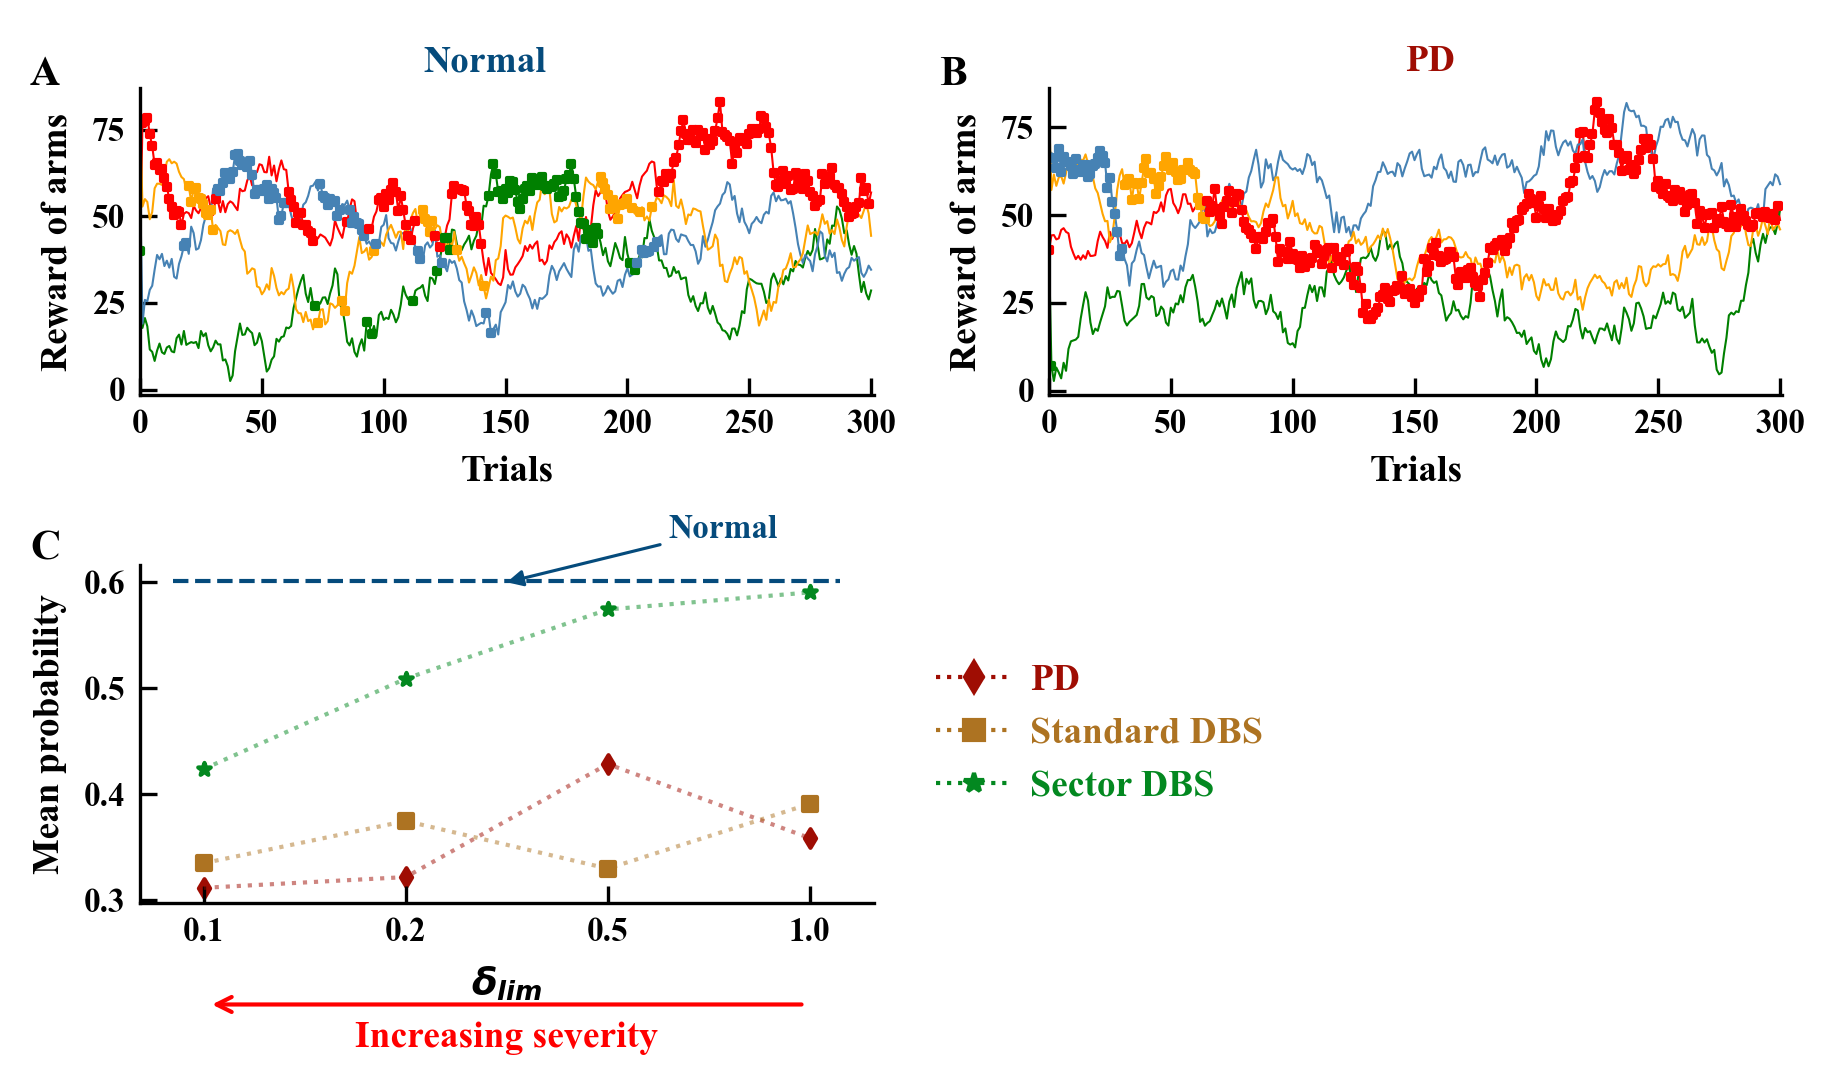

In [ ]:
lat_arr_index = 3
fig = plt.figure(figsize=(6, 3.5), facecolor='white')
gs = fig.add_gridspec(nrows=2, ncols=2, width_ratios=[1,1], height_ratios=[1, 1.1], hspace=0.01)

ax_normal = fig.add_subplot(gs[0, 0])   # top-left
ax_PD     = fig.add_subplot(gs[0, 1])   # top-right
ax_all    = fig.add_subplot(gs[1, 0]) # bottom spanning two columns
ax_legend  = fig.add_subplot(gs[1,1])  # narrow right column for legends

# hide legend axis background
ax_legend.axis('off')

# Top-left: Normal lines + picks
trials_normal = arm_rew_normal.shape[1]
time_normal = np.arange(trials_normal)
for i in range(4):
    ax_normal.plot(time_normal, arm_rew_normal[i, :]*100, color=color_map_normal[i], label=f'arm {i}', linewidth=0.5)
for t, pick in enumerate(chosen_normal):
    ax_normal.scatter(t, arm_rew_normal[pick, t]*100, color=color_map_normal[pick], s=2.25, marker='s', zorder = 2)
ax_normal.set_xlabel('Trials')
ax_normal.set_ylabel('Reward of arms')
ax_normal.set_xlim(0, trials_normal)

handles = [Line2D([0], [0], color=colors['normal'], lw=0)]
          
legend = ax_normal.legend(handles, ['Normal'], loc='upper right', frameon=False, fontsize=9, bbox_to_anchor=(0.6, 1.25))
for txt, col in zip(legend.get_texts(), [colors['normal']]):
    txt.set_color(col)


# Top-right: PD lines + picks
trials_PD = arm_rew_PD.shape[1]
time_PD = np.arange(trials_PD)
for i in range(4):
    ax_PD.plot(time_PD, arm_rew_PD[i, :]*100, color=color_map_PD[i], label=f'arm {i}', linewidth=0.5)
for t, pick in enumerate(chosen_PD):
    ax_PD.scatter(t, arm_rew_PD[pick, t]*100, color=color_map_PD[pick], s=2.25, marker='s', zorder = 2)
ax_PD.set_xlabel('Trials')
ax_PD.set_ylabel('Reward of arms')
ax_PD.set_xlim(0, trials_PD)
handles = [Line2D([0], [0], color=colors['PD'], lw=0)]
          
legend = ax_PD.legend(handles, ['PD'], loc='upper right', frameon=False, fontsize=9, bbox_to_anchor=(0.6, 1.25))
for txt, col in zip(legend.get_texts(), [colors['PD']]):
    txt.set_color(col)


ax_all.scatter(np.arange(4), Mean_PD_all[lat_arr_index], marker='d', color=colors['PD'], s=10)
ax_all.scatter(np.arange(4), Mean_std_DBS_all[lat_arr_index], marker='s', color= colors['std_DBS'], s=10)
ax_all.scatter(np.arange(4), Mean_sector_DBS_all[lat_arr_index], marker='*', color=colors['sector_DBS'], s=10)
ax_all.plot(np.arange(4), Mean_PD_all[lat_arr_index], color=colors['PD'], linewidth=1, alpha=0.5, linestyle='dotted')
ax_all.plot(np.arange(4), Mean_std_DBS_all[lat_arr_index], color=colors['std_DBS'], linewidth=1, alpha=0.5, linestyle='dotted')
ax_all.plot(np.arange(4), Mean_sector_DBS_all[lat_arr_index], color= colors['sector_DBS'], linewidth=1, alpha=0.5, linestyle='dotted')


ax_all.set_xlabel('$\delta_{lim}$')
ax_all.set_ylabel('Mean probability')
ax_all.set_xticks(np.arange(4), del_lim_arr)

x_min, x_max = ax_all.get_xlim()
ax_all.hlines(np.mean(prob_normal)-0.02, x_min, x_max, color=colors['normal'], linestyle='--', linewidth=1.0)
x_ann = x_min + 0.5 * (x_max - x_min)               # near left/y-axis
y_ann = 0.6
y_text = 0.65

ax_all.annotate(
    'Normal',
    xy=(x_ann, y_ann),
    xytext=(x_ann + 0.8, y_text),
    arrowprops=dict(arrowstyle='-|>', color=colors['normal'], lw=0.75, shrinkA=0, shrinkB=0),
    fontsize=8, fontweight='bold', color=colors['normal'], va='center'
)

x_values = np.arange(len(del_lim_arr))
x_start = x_values[-1] 
x_end = x_values[0] 
y_pos = -0.3
ax_all.annotate(
    '',  # No text at the arrow tip
    xy=(x_end, y_pos),           # Arrow tip coordinates (end point)
    xytext=(x_start, y_pos),     # Text and arrow tail coordinates (start point)
    xycoords=('data', 'axes fraction'), # Use data coords for x, axes fraction for y
    textcoords=('data', 'axes fraction'),
    arrowprops=dict(
        arrowstyle="->",         # Style of the arrow head
        color='red',           # Color of the arrow
        linewidth=1
    )
)
# 
# 4. Add the text at the center of the arrow.
ax_all.annotate(
    'Increasing severity',
    xy=((x_start + x_end) / 2, y_pos-0.1), # Center point of the arrow
    xycoords=('data', 'axes fraction'),
    ha='center',                 # Horizontal alignment
    va='center',                 # Vertical alignment (center on the arrow line)
    fontsize=9,
    color='red'
)


handles = [Line2D([0], [0], color=colors['PD'], lw=1, marker = 'd', markerfacecolor=colors['PD'], linestyle=':'),
           Line2D([0], [0], color=colors['std_DBS'], lw=1, marker = 's', markerfacecolor=colors['std_DBS'], linestyle=':'),
           Line2D([0], [0], color=colors['sector_DBS'], lw=1, marker = '*', markerfacecolor=colors['sector_DBS'], linestyle=':')]
labels = ['PD', 'Standard DBS', 'Sector DBS']
legend = ax_legend.legend(handles, labels, loc='center left', frameon=False, fontsize=9, bbox_to_anchor=(-0.2, 0.5))
for txt, col in zip(legend.get_texts(), [colors['PD'], colors['std_DBS'], colors['sector_DBS']]):
    txt.set_color(col)

# add subplot letters
labels = ['A', 'B', 'C']
for n, ax in enumerate([ax_normal, ax_PD, ax_all]):
    ax.text(-0.15, 1.1, labels[n], transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')


# 
# plt.savefig('plots/main_plot_restless.png', bbox_inches='tight')
# plt.savefig('plots/main_plot_restless.pdf', bbox_inches='tight')
# plt.savefig('plots/main_plot_restless.svg', bbox_inches='tight')

plt.show()


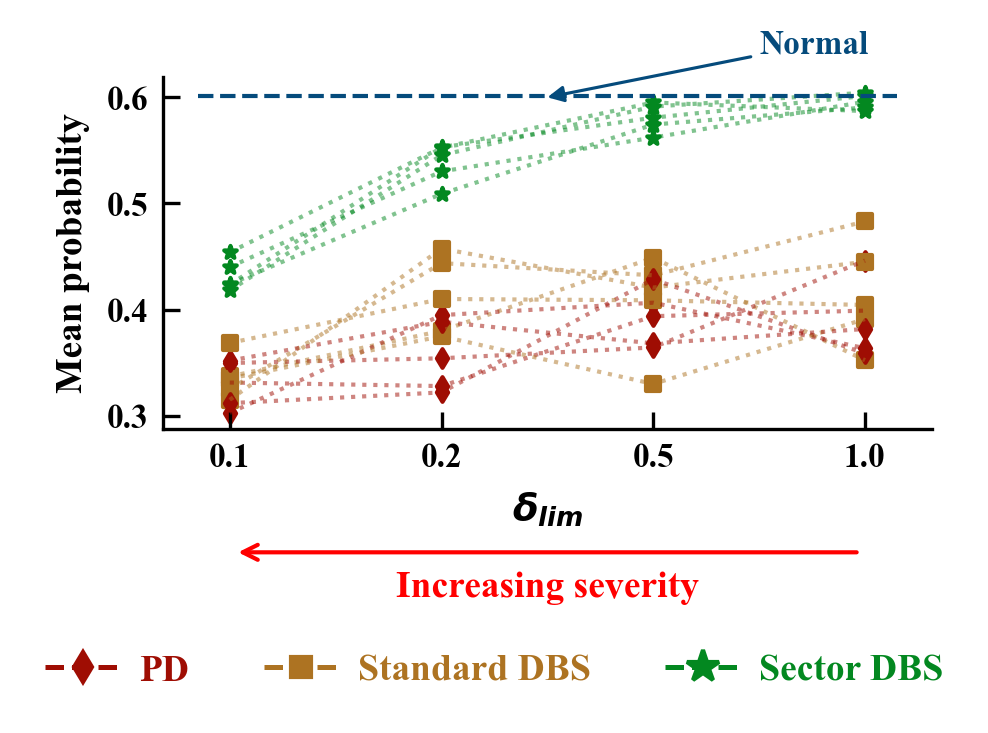

In [ ]:
fig = plt.figure(figsize=(3, 2), facecolor='white')

for i in range(5):
    plt.scatter(np.arange(4), Mean_PD_all[i], marker='d', color=colors['PD'], s=10)
    plt.scatter(np.arange(4), Mean_std_DBS_all[i], marker='s', color= colors['std_DBS'], s=10)
    plt.scatter(np.arange(4), Mean_sector_DBS_all[i], marker='*', color=colors['sector_DBS'], s=10)
    plt.plot(np.arange(4), Mean_PD_all[i], color=colors['PD'], linewidth=1, alpha=0.5, linestyle='dotted')
    plt.plot(np.arange(4), Mean_std_DBS_all[i], color=colors['std_DBS'], linewidth=1, alpha=0.5, linestyle='dotted')
    plt.plot(np.arange(4), Mean_sector_DBS_all[i], color= colors['sector_DBS'], linewidth=1, alpha=0.5, linestyle='dotted')



plt.xlabel('$\delta_{lim}$')
plt.ylabel('Mean probability')
plt.xticks(np.arange(4), del_lim_arr)

# Add a single legend for all conditions at the bottom of the figure
handles = [
    Line2D([0], [0], color=colors['PD'], marker='d', linestyle='--', label='PD'),
    Line2D([0], [0], color=colors['std_DBS'], marker='s', linestyle='--', label='Standard DBS'),
    Line2D([0], [0], color=colors['sector_DBS'], marker='*', linestyle='--', label='Sector DBS', markersize = 8),
]
legend = fig.legend(handles=handles, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.175), frameon=False, fontsize=9)
for txt, col in zip(legend.get_texts(), [colors['PD'], colors['std_DBS'], colors['sector_DBS']]):
    txt.set_color(col)
x_values = np.arange(len(del_lim_arr))
x_start = x_values[-1] 
x_end = x_values[0] 
y_pos = -0.35
plt.annotate(
    '',  # No text at the arrow tip
    xy=(x_end, y_pos),           # Arrow tip coordinates (end point)
    xytext=(x_start, y_pos),     # Text and arrow tail coordinates (start point)
    xycoords=('data', 'axes fraction'), # Use data coords for x, axes fraction for y
    textcoords=('data', 'axes fraction'),
    arrowprops=dict(
        arrowstyle="->",         # Style of the arrow head
        color='red',           # Color of the arrow
        linewidth=1
    )
)
# 
# 4. Add the text at the center of the arrow.
plt.annotate(
    'Increasing severity',
    xy=((x_start + x_end) / 2, y_pos-0.1), # Center point of the arrow
    xycoords=('data', 'axes fraction'),
    ha='center',                 # Horizontal alignment
    va='center',                 # Vertical alignment (center on the arrow line)
    fontsize=9,
    color='red'
)


x_min, x_max = plt.xlim()
plt.hlines(np.mean(prob_normal)-0.02, x_min, x_max, color=colors['normal'], linestyle='--', linewidth=1.0)
x_ann = x_min + 0.5 * (x_max - x_min)               # near left/y-axis
y_ann = 0.6
y_text = 0.65

plt.annotate(
    'Normal',
    xy=(x_ann, y_ann),
    xytext=(x_ann + 1, y_text),
    arrowprops=dict(arrowstyle='-|>', color=colors['normal'], lw=0.75, shrinkA=0, shrinkB=0),
    fontsize=8, fontweight='bold', color=colors['normal'], va='center'
)


# plt.text(-0.125, 0.375, 'A', transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')

# 
# plt.savefig('plots/supplementary_plot_restless.png', bbox_inches='tight')
# plt.savefig('plots/supplementary_plot_restless.pdf', bbox_inches='tight')
# plt.savefig('plots/supplementary_plot_restless.svg', bbox_inches='tight')